# Algorithme « Metropolis à marches aléatoires » ("random-walk Metropolis").

## Importation des bibliothèques

In [1]:
# -q : quiet --> réduction des messages
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import time
import functions.generation as generation
from scipy.stats import invgamma, dirichlet
from scipy.stats import multivariate_normal
from scipy.linalg import cholesky_banded, cho_solve_banded

np.random.seed(20798)

In [3]:
# génération de données

x_star, mu_list, sigma2_list = generation.generate_data(
    generation.n, generation.T, 
    generation.alpha, generation.zeta)

## Calcul de la vraisemblance

Le modèle de l’article est un modèle hiérarchique MA(2). Soit 

$$X = (X_1, X_2, \dots, X_T)$$


Chaque composante du vecteur $X$ est gaussienne, car elle est une combinaison linéaire de variables gaussiennes. Cependant, les composantes de ce vecteur ne sont pas indépendantes par construction.

$$
\mathrm{Var}(X_t)
= \mathrm{Cov}\big(y_t + \mu_1 y_{t-1} + \mu_2 y_{t-2},\; y_t + \mu_1 y_{t-1} + \mu_2 y_{t-2}\big)
$$

avec $y_t \sim \mathcal{N}(0, \sigma^2)$.

Par indépendance du bruit blanc (les innovations) :

$$
\mathrm{Var}(X_t) = \sigma^2 (1 + \mu_1^2 + \mu_2^2)
$$

On obtient les covariances suivantes :

$$
\mathrm{Cov}(X_t, X_{t-1}) = \mathrm{Cov}(X_t, X_{t+1})
= \sigma^2 (\mu_1 + \mu_1 \mu_2)
$$

$$
\mathrm{Cov}(X_t, X_{t-2}) = \mathrm{Cov}(X_t, X_{t+2})
= \sigma^2 \mu_2
$$

Ainsi, la matrice de variance-covariance de $X$, conditionnellement aux paramètres, est de la forme :

$$
\Sigma(\mu, \sigma^2) = \sigma^2
\begin{pmatrix}
\gamma_0 & \gamma_1 & \gamma_2 & 0 & \cdots & 0 \\
\gamma_1 & \gamma_0 & \gamma_1 & \gamma_2 & \ddots & \vdots \\
\gamma_2 & \gamma_1 & \gamma_0 & \gamma_1 & \ddots & 0 \\
0 & \gamma_2 & \gamma_1 & \gamma_0 & \ddots & \gamma_2 \\
\vdots & \ddots & \ddots & \ddots & \ddots & \gamma_1 \\
0 & \cdots & 0 & \gamma_2 & \gamma_1 & \gamma_0
\end{pmatrix}
$$

### Posterior et RWMH

Par la règle de Bayes, et comme les séries sont indépendantes :

$$\log p(\mu_j, \sigma^2_j \mid \mathbf{x}_j) = \log p(\mathbf{x}_j \mid \mu_j, \sigma^2_j) + \log p(\mu_j) + \log p(\sigma^2_j) + \text{cst}$$

La constante est du au changement de $\mu$ vers $\beta$.
On cible ce posterior série par série avec une marche aléatoire gaussienne sur $(\mu_{j,1}, \mu_{j,2}, \sigma^2_j)$. La proposition est symétrique donc la condition pour l'algorithme de Metropolis est simplement :

$$\log \alpha = \log p(\theta^\star \mid \mathbf{x}_j) - \log p(\theta^{(t)} \mid \mathbf{x}_j)$$

avec $\theta = (\mu_{j,1}, \mu_{j,2}, \sigma^2_j)$. Si $\sigma^2_j \leq 0$ est proposé, on rejette directement.


In [5]:
def log_target(x, mu, sigma2, alpha, zeta):
    """
    log densité cible = log vraisemblance + log prior
    """
    T = len(x)
    #var    = sigma2 * (1 + mu[0]**2 + mu[1]**2)
    #gamma1 = sigma2 * (mu[0] + mu[0]*mu[1])
    #gamma2 = sigma2 * mu[1]

    #Sigma = np.zeros((T, T))
    #for i in range(T):
        #Sigma[i, i] = var
        #if i+1 < T:
            #Sigma[i, i+1] = gamma1
            #Sigma[i+1, i] = gamma1
        #if i+2 < T:
            #Sigma[i, i+2] = gamma2
            #Sigma[i+2, i] = gamma2

    #sign, log_det = np.linalg.slogdet(Sigma)
    #quad = x @ np.linalg.solve(Sigma, x)
    #log_lik = -0.5 * (T * np.log(2 * np.pi) + log_det + quad)
    
    # regarder d'un point de vue des innovations et pas des données x => latent variables?
    eps = np.zeros(T)

    for t in range(T):
        eps[t] = x[t]
        if t-1 >= 0:
            eps[t] -= mu[0] * eps[t - 1]
        if t-2 >= 0:
            eps[t] -= mu[1] * eps[t - 2]

    quad = np.sum(eps**2)

    log_lik = -0.5 * (T * np.log(2 * np.pi * sigma2) + quad / sigma2)

    # prior
    s  = (mu[1] + 1) / 2
    b1 = (mu[0] + s) / 2
    b2 = s - b1
    b3 = 1 - b1 - b2
    beta = np.array([b1, b2, b3])

    if np.any(beta <= 0) or np.any(beta >= 1) or sigma2 <= 0:
        return -np.inf

    log_prior = dirichlet.logpdf(beta, alpha) + invgamma.logpdf(sigma2, zeta[0], scale=zeta[1])

    return log_lik + log_prior

# 'Component-wise' Metropolis-Hastings 
def metropolis_kernel(x, theta, step_mu, step_sigma2, alpha, zeta):
    # on mets à jour sur chaque dimension ET PAS de manière jointe
    # sinon on risque d'avoir certaines dimensions très très mauvaises
    """
    theta = (mu1, mu2, sigma2)
    """
    mu_cur = theta[:2].copy()
    sigma2_cur = theta[2]
    acc = 0

    # --- mise à jour de mu1 ---
    mu_prop = mu_cur.copy()
    mu_prop[0] += step_mu * np.random.randn()
    log_alpha = (log_target(x, mu_prop, sigma2_cur, alpha, zeta)
                  - log_target(x, mu_cur,  sigma2_cur, alpha, zeta))
    if np.log(np.random.rand()) < log_alpha:
        mu_cur = mu_prop
        acc += 1

    # --- mise à jour de mu2 ---
    mu_prop = mu_cur.copy()
    mu_prop[1] += step_mu * np.random.randn()
    log_alpha = (log_target(x, mu_prop, sigma2_cur, alpha, zeta)
                  - log_target(x, mu_cur,  sigma2_cur, alpha, zeta))
    
    if np.log(np.random.rand()) < log_alpha:
        mu_cur = mu_prop
        acc += 1

    # --- mise à jour de sigma2 ---
    sigma2_prop = sigma2_cur + step_sigma2 * np.random.randn()
    if sigma2_prop > 0:
        log_alpha = (log_target(x, mu_cur, sigma2_prop, alpha, zeta)
                   - log_target(x, mu_cur, sigma2_cur,  alpha, zeta))
        if np.log(np.random.rand()) < log_alpha:
            sigma2_cur = sigma2_prop
            acc += 1

    theta_new = np.array([mu_cur[0], mu_cur[1], sigma2_cur])
    return {'val': theta_new, 'acc': acc / 3}

In [6]:
def rwmh_one_series(x, alpha, zeta, n_iter=10_000,
                    step_mu=0.1, step_sigma2=0.2, seed=20798):
    
    np.random.seed(seed)

    mu_init = [0.1, -0.5]
    sigma2_init = 1.0

    N  = n_iter
    s = 0
    chain = np.empty((N, 3))
    chain[0] = [mu_init[0], mu_init[1], sigma2_init]

    for n in range(1, N):
        output = metropolis_kernel(x, chain[n-1], step_mu, step_sigma2, alpha, zeta)
        chain[n] = output['val']
        s += output['acc']

    acc_rate = s / N
    return chain, acc_rate

In [7]:
chain, acc = rwmh_one_series(
        x_star[0], generation.alpha, generation.zeta, 
        n_iter = 100_000, step_mu=0.1, step_sigma2=0.1, seed=20798
    )

In [8]:
def plot_chain(chain, burnin, true_mu, true_sigma2):
    post = chain[burnin:]
    true_vals = [true_mu[0], true_mu[1], true_sigma2]
    param_names = [r"$\mu_1$", r"$\mu_2$", r"$\sigma^2$"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for k in range(3):
        ax = axes[k]
        ax.hist(post[:, k], bins=40, density=True)
        ax.axvline(true_vals[k], color='#D85A30', lw=2,
                   label=f'vraie valeur = {true_vals[k]:.3f}')
        ax.axvline(post[:, k].mean(), color='white', lw=1.5,
                   linestyle='--', label=f'moyenne = {post[:, k].mean():.3f}')
        ax.set_title(param_names[k])
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

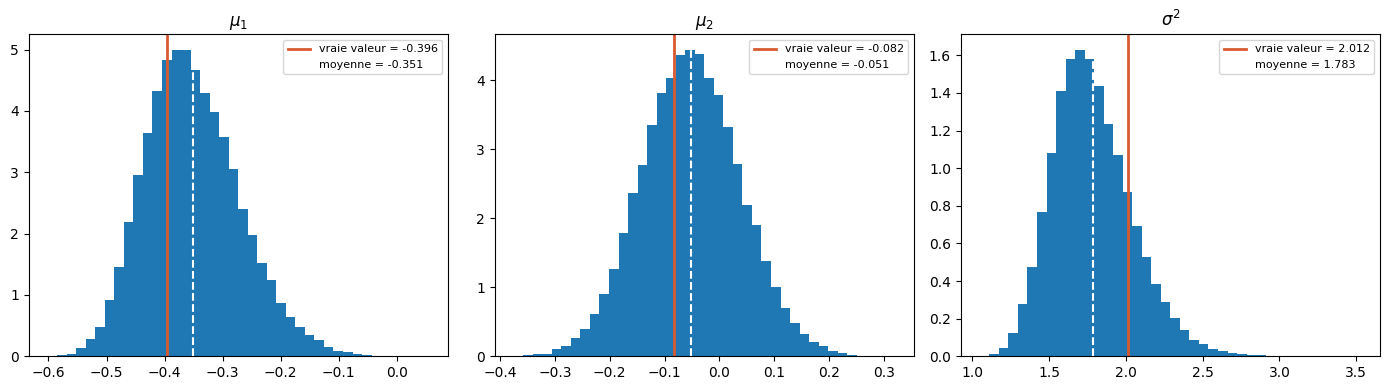

In [9]:
plot_chain(chain, 10_000, mu_list[0], sigma2_list[0])

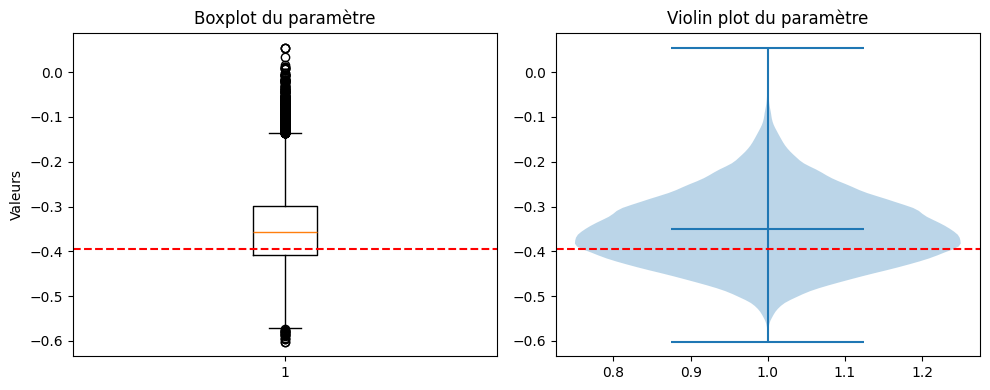

In [ ]:
plt.figure(figsize=(10, 4))
post = chain[10_000:]
# Boxplot
plt.subplot(1, 2, 1)
plt.boxplot(post[:,0])
plt.axhline(mu_list[0][0], color='red', linestyle='--', label='vraie valeur')
plt.title("Boxplot du paramètre")
plt.ylabel("Valeurs")

# Violin plot
plt.subplot(1, 2, 2)
plt.violinplot(post[:,0], showmeans=True)
plt.axhline(mu_list[0][0], color='red', linestyle='--', label='vraie valeur')
plt.title("Violin plot du paramètre")

plt.tight_layout()
plt.show()

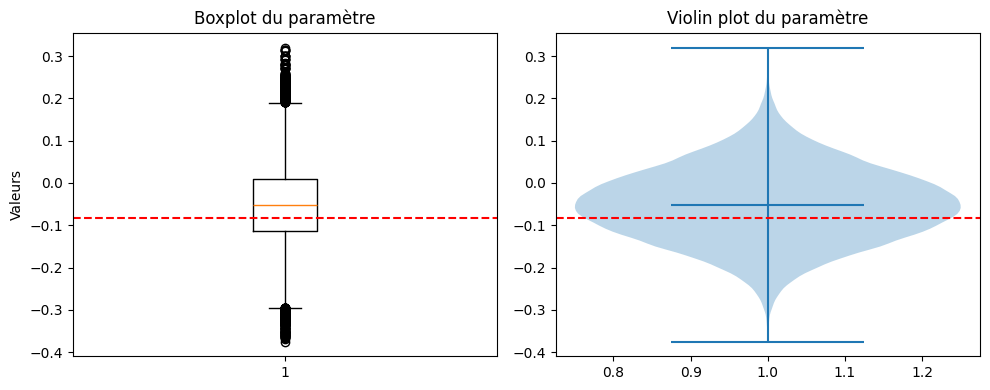

In [11]:
plt.figure(figsize=(10, 4))
post = chain[10_000:]
# Boxplot
plt.subplot(1, 2, 1)
plt.boxplot(post[:,1])
plt.axhline(mu_list[0][1], color='red', linestyle='--', label='vraie valeur')
plt.title("Boxplot du paramètre")
plt.ylabel("Valeurs")

# Violin plot
plt.subplot(1, 2, 2)
plt.violinplot(post[:,1], showmeans=True)
plt.axhline(mu_list[0][1], color='red', linestyle='--', label='vraie valeur')
plt.title("Violin plot du paramètre")

plt.tight_layout()
plt.show()

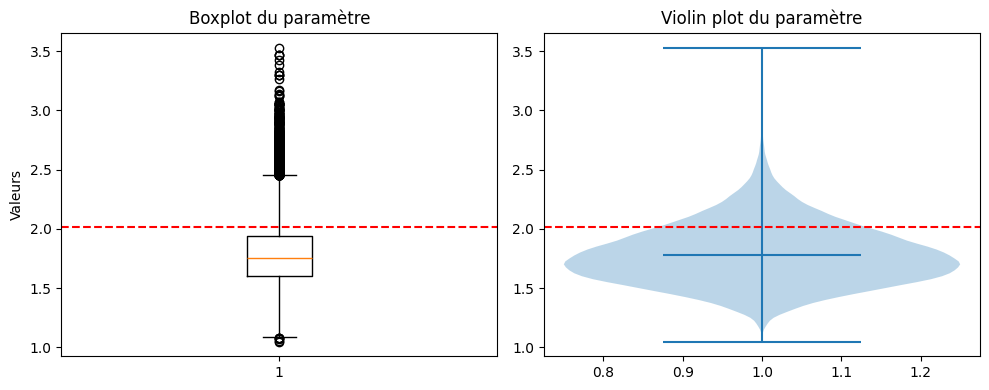

In [14]:
plt.figure(figsize=(10, 4))
post = chain[10_000:]
# Boxplot
plt.subplot(1, 2, 1)
plt.boxplot(post[:,2])
plt.axhline(sigma2_list[0], color='red', linestyle='--', label='vraie valeur')
plt.title("Boxplot du paramètre")
plt.ylabel("Valeurs")

# Violin plot
plt.subplot(1, 2, 2)
plt.violinplot(post[:,2], showmeans=True)
plt.axhline(sigma2_list[0], color='red', linestyle='--', label='vraie valeur')
plt.title("Violin plot du paramètre")

plt.tight_layout()
plt.show()

In [ ]:
# acceptance rate vraiment un peu trop élévé ! d'ou vient ce soucis?
acc

0.7133866666665207

In [15]:
chain1, acc1 = rwmh_one_series(
        x_star[1], generation.alpha, generation.zeta, 
        n_iter = 100_000, step_mu=0.1, step_sigma2=0.1, seed=20798
    )

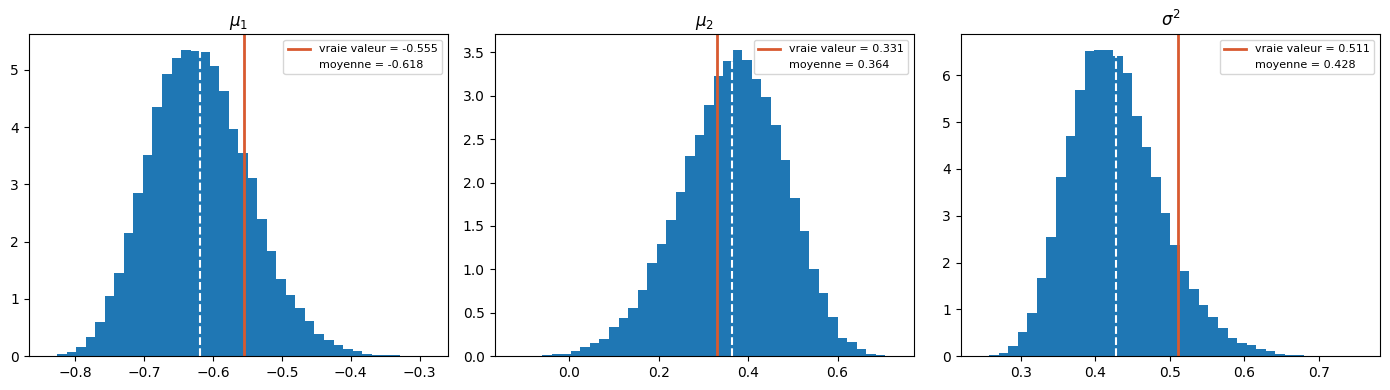

In [16]:
plot_chain(chain1, 10_000, mu_list[1], sigma2_list[1])

In [ ]:
# bcp mieux comme acceptance rate par rapport à la première série et résultats plutot cool
acc1

0.5269133333333165